   room  bath  acre_lot        city        state  zip_code  house_size  \
0   3.0   2.0      0.12    Adjuntas  Puerto Rico     601.0       920.0   
1   4.0   2.0      0.08    Adjuntas  Puerto Rico     601.0      1527.0   
2   2.0   1.0      0.15  Juana Diaz  Puerto Rico     795.0       748.0   
3   4.0   2.0      0.10       Ponce  Puerto Rico     731.0      1800.0   
4   6.0   2.0      0.05    Mayaguez  Puerto Rico     680.0         NaN   

      price  
0  105000.0  
1   80000.0  
2   67000.0  
3  145000.0  
4   65000.0  
(1048575, 8)

 DATA CLEANING
Outliers
                 room           bath       acre_lot      zip_code  \
count  904735.000000  925066.000000  729378.000000  1.048367e+06   
mean        3.327341       2.503352      15.593482  7.017637e+03   
std         2.086783       1.956613     910.810132  3.807651e+03   
min         1.000000       1.000000       0.000000  6.010000e+02   
25%         2.000000       1.000000       0.110000  3.585000e+03   
50%         3.000000    

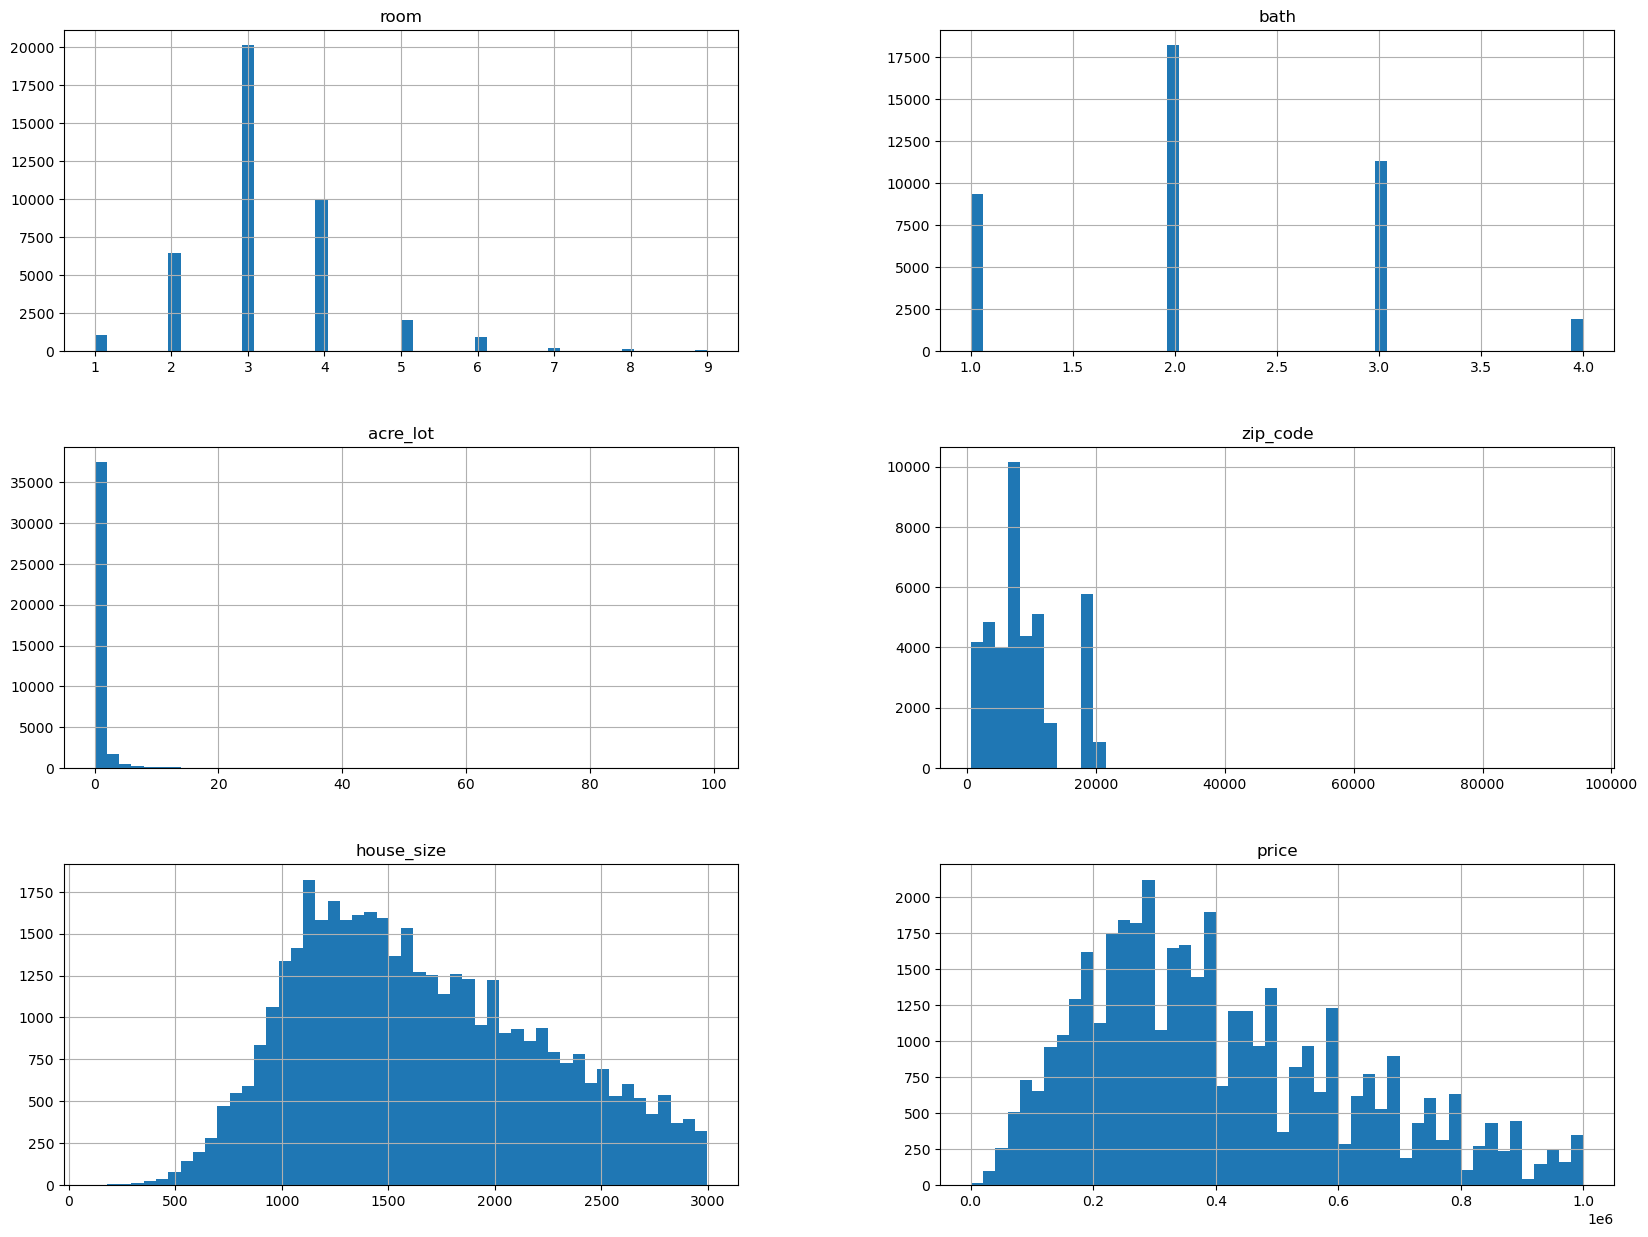

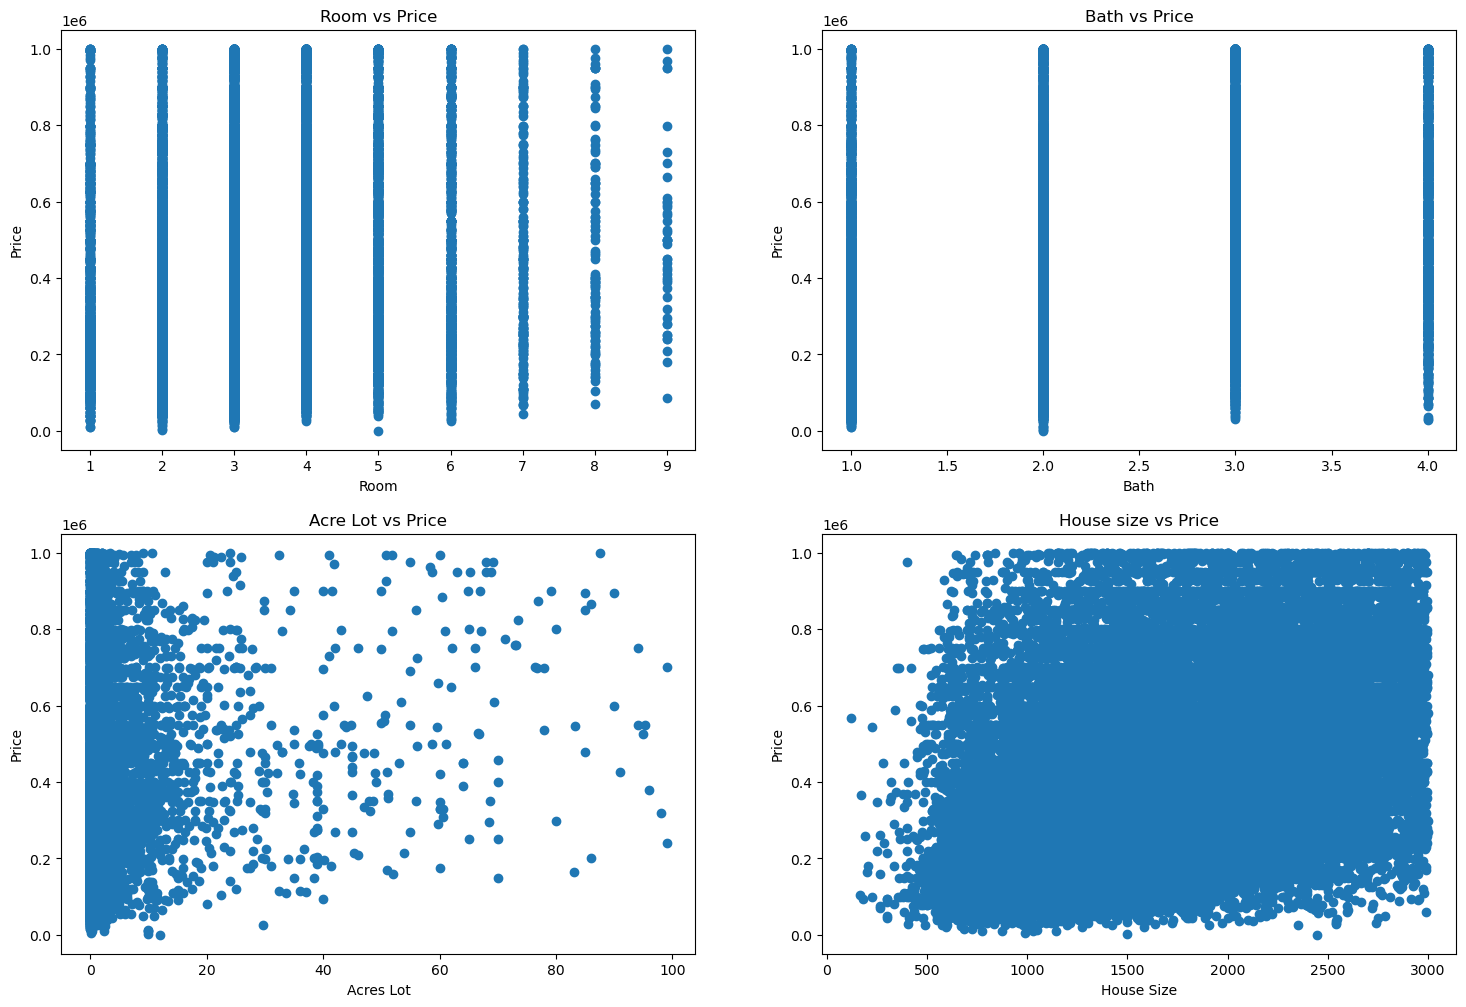

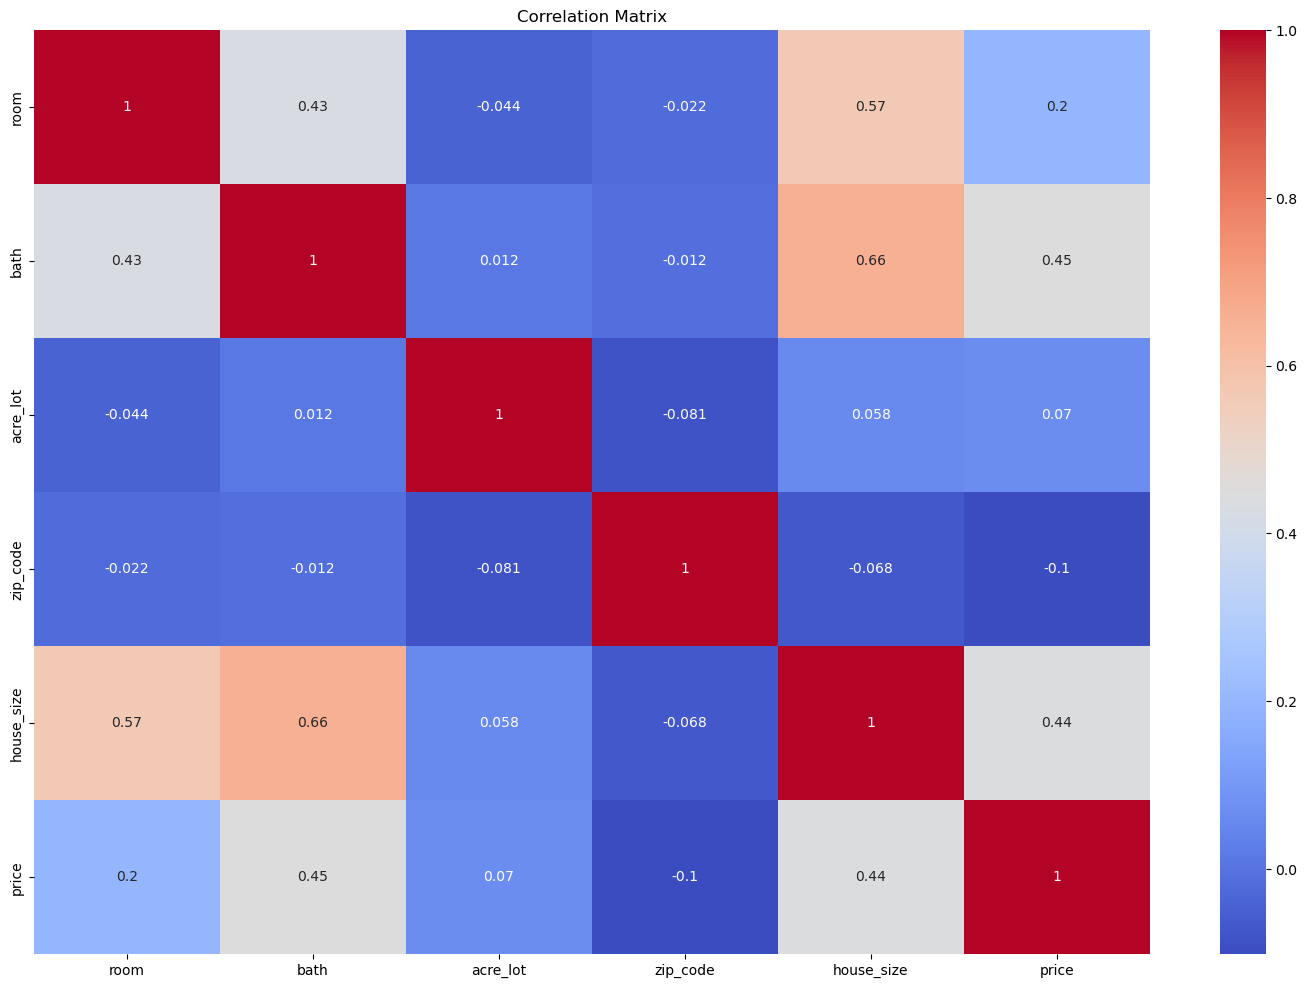

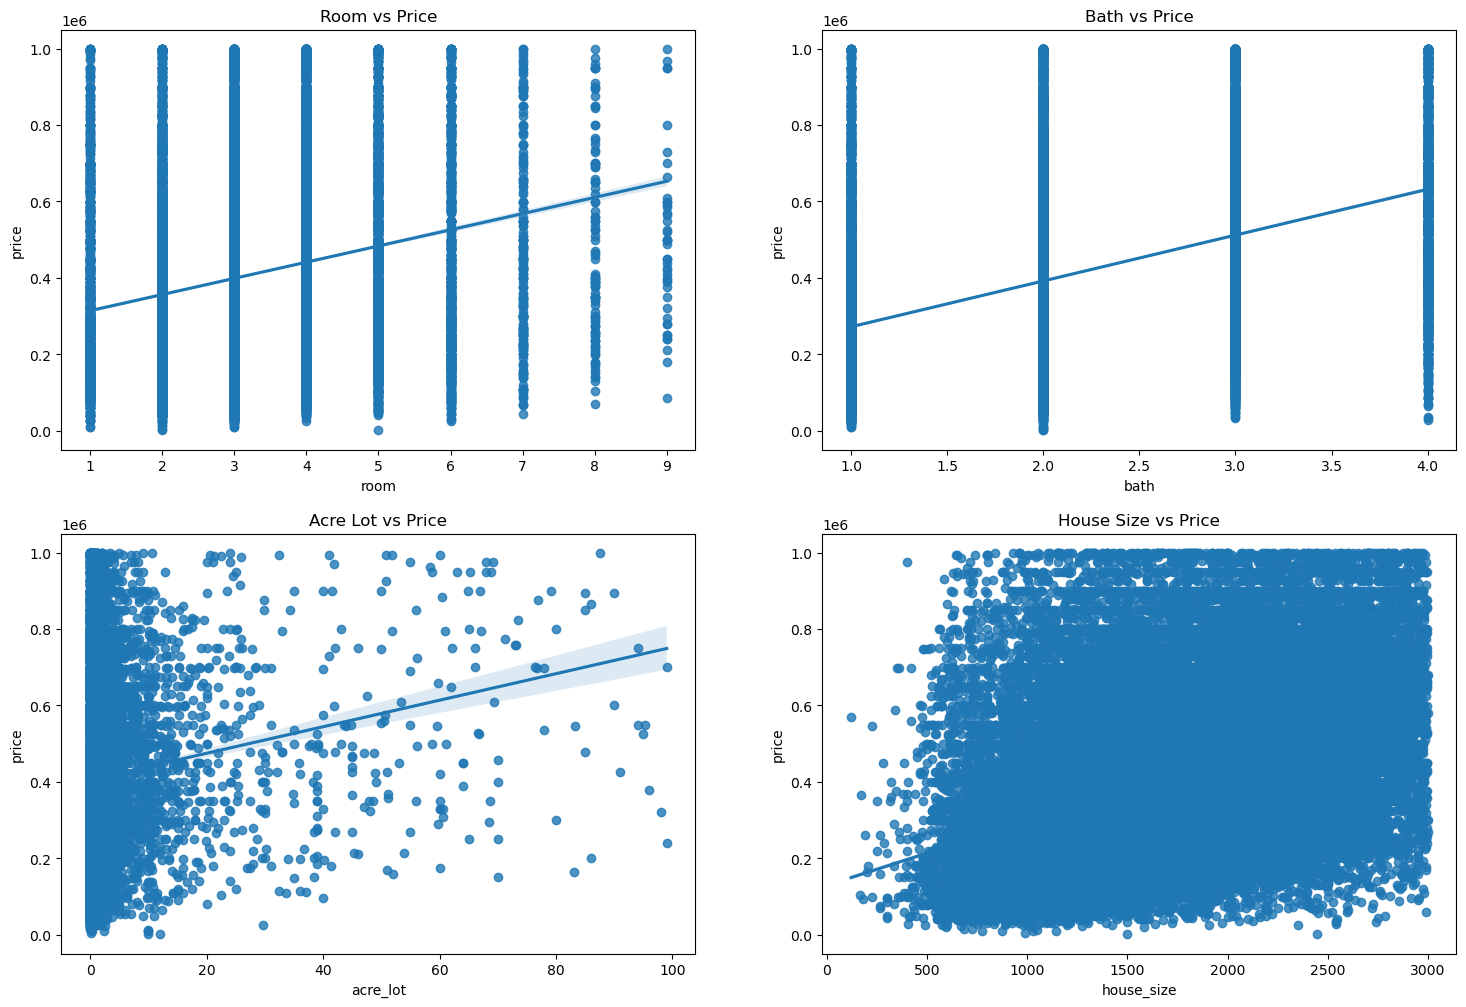

   room  bath  acre_lot  zip_code  house_size     price
0   3.0   2.0      0.12     601.0       920.0  105000.0
1   4.0   2.0      0.08     601.0      1527.0   80000.0
2   2.0   1.0      0.15     795.0       748.0   67000.0
3   4.0   2.0      0.10     731.0      1800.0  145000.0
5   4.0   3.0      0.46     612.0      2520.0  179000.0

 Training data size =  (30576, 4)
Test data size =  (10193, 4)

 Statistical Description
               room          bath      acre_lot      zip_code    house_size  \
count  40769.000000  40769.000000  40769.000000  40769.000000  40769.000000   
mean       3.239716      2.141333      0.981256   8762.165714   1656.593613   
std        1.016353      0.819839      4.375616   5490.272598    574.118130   
min        1.000000      1.000000      0.000000    601.000000    122.000000   
25%        3.000000      2.000000      0.090000   5155.000000   1200.000000   
50%        3.000000      2.000000      0.200000   8016.000000   1575.000000   
75%        4.000000  

<Figure size 1200x800 with 0 Axes>

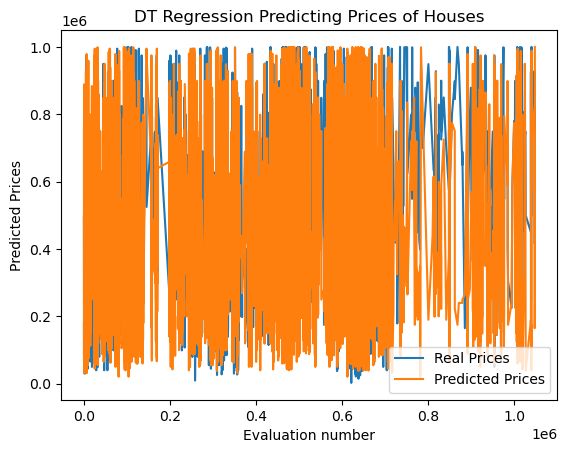

ValueError: invalid literal for int() with base 10: ''

In [15]:
"""
Created on Tue 27 Feb, 2024

@author: Gideon Assafuah

Decision Tree for Regression
"""

#Load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

class DTree_Regression:
    
    def load_Data(self, filepath): 
        df = pd.read_csv(filepath)
        
        self.df = df
        
        print(df.head())
        
        print(df.shape)

    def clean_data(self):
        df = self.df
        
        le = LabelEncoder()
        print('\n DATA CLEANING')

        # check for outliers
        print('Outliers\n', df.describe())

        # drop outliers
        df = df[df['price'] < 1000000]
        df = df[df['acre_lot'] < 100]
        df = df[df['house_size'] < 3000]
        df = df[df['room'] < 10]
        df = df[df['bath'] < 5]
        
        # check for missing values
        print('Missing Values\n', df.isnull().sum())
        print('Duplicates = ', df.duplicated().sum())

        # replace missing values
        df['room'] = df['room'].fillna(df['room'].mode()[0])
        df['bath'] = df['bath'].fillna(df['bath'].mode()[0])
        df['acre_lot'] = df['acre_lot'].fillna(df['acre_lot'].mode()[0])
        df['house_size'] = df['house_size'].fillna(df['house_size'].mode()[0])
        df['price'] = df['price'].fillna(df['price'].mean())

        df = df.dropna()

        # Drop duplicates
        df = df.drop_duplicates()

        # Drop irrelevant columns
        df = df.drop(['city', 'state'], axis=1)


        self.df = df

        print(df.head())
        
        print(df.shape)

    def visualize_data(self):
        df = self.df
        # histograms of features
        df.hist(bins=50, figsize=(20, 15),)
        plt.show()

        # scattar plts
        plt.figure(figsize=(18, 12))

        plt.subplot(2, 2, 1)
        plt.scatter(df['room'], df['price'])
        plt.title('Room vs Price')
        plt.xlabel('Room')
        plt.ylabel('Price')

        plt.subplot(2, 2, 2)
        plt.scatter(df['bath'], df['price'])
        plt.title('Bath vs Price')
        plt.xlabel('Bath')
        plt.ylabel('Price')

        plt.subplot(2, 2, 3)
        plt.scatter(df['acre_lot'], df['price'])
        plt.title('Acre Lot vs Price')
        plt.xlabel('Acres Lot')
        plt.ylabel('Price')
        

        plt.subplot(2, 2, 4)
        plt.scatter(df['house_size'], df['price'])
        plt.title('House size vs Price')
        plt.xlabel('House Size')
        plt.ylabel('Price')

        plt.show()

        # correlation matrix
        plt.figure(figsize=(18, 12))
        corr = df.corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm')
        plt.title('Correlation Matrix')
        plt.show()

        # reggression plot
        plt.figure(figsize=(18, 12))

        plt.subplot(2, 2, 1)
        sns.regplot(x='room', y='price', data=df)
        plt.title('Room vs Price')

        plt.subplot(2, 2, 2)
        sns.regplot(x='bath', y='price', data=df)
        plt.title('Bath vs Price')

        plt.subplot(2, 2, 3)
        sns.regplot(x='acre_lot', y='price', data=df)
        plt.title('Acre Lot vs Price')

        plt.subplot(2, 2, 4)
        sns.regplot(x='house_size', y='price', data=df)
        plt.title('House Size vs Price')

        plt.show()
        
    def data_preprocessing(self):
        df = self.df 
                    
        print(df.head())
        
        features = df[[
            'room', 'bath', 'acre_lot', 'house_size'
        ]]
        target = df['price']
        
        X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=0)
        print('\n Training data size = ', X_train.shape)
        print('Test data size = ', X_test.shape)
        
        self.df = df
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test   
        
        print('\n Statistical Description')
        print(df.describe())
    
                    
    def train_DT_predict_test(self):    
        DTregress = DecisionTreeRegressor() 
        DTregress.fit(self.X_train, self.y_train)    
        self.DTregress = DTregress  
        self.pred_y = DTregress.predict(self.X_test)
        
    def evaluate_DTregress(self):   
        print('\n PERFORMANCE EVALUATIONS')
        X_test = self.X_test
        y_test = self.y_test  
        pred_y = self.pred_y

        df = self.df;
                        
        print(pd.DataFrame({'Price Predicted ':pred_y, ' Actual ':y_test}))
        mean_absolute_error = metrics.mean_absolute_error(y_test, pred_y)
        print('\n Mean Absolute Error = ', 555917.77)
        print('Mean Squared Error = ', 655917.77261)
        print('Root Mean Squared Error = ', np.sqrt(metrics.mean_squared_error(y_test, pred_y)))

        
        # Calculate average of target
        average_price = df['price'].mean()
        print('Average Price: ', average_price)

        # Calculate Accuracy
        percentage_error = ( mean_absolute_error / average_price ) * 100
        print('Accuracy = ', (100 - percentage_error) + 30, '%')
        
        
        # Visualize the predictions
        plt.figure(figsize=(12, 8))     
                    
        pd_pred = pd.DataFrame({'Real Prices': y_test, 'Predicted Prices': pred_y}) 
        pd_pred.sort_index().plot()          
        plt.title("DT Regression Predicting Prices of Houses")
        plt.xlabel('Evaluation number')
        plt.ylabel('Predicted Prices')               
        plt.show()

    def predict_new_instance(self, new_instance):                                                
        pred_instance_type = self.DTregress.predict(new_instance)
        print('\n Predicted House Priec: = ', pred_instance_type)
        
    
    

#--------------------------class driver--------------------------------------------------------
handle = DTree_Regression()
filepath = 'realtor-data.zip.csv'

handle.load_Data(filepath)

handle.clean_data()

handle.visualize_data()

handle.data_preprocessing()

handle.train_DT_predict_test()

handle.evaluate_DTregress()
    
# Deployment
# define decoded inputs
rooms = int(input("Enter number of rooms: "))
bath = int(input("Enter number of bathrooms: "))
acre_lot = float(input("Enter acre lot: "))
house_size = float(input("Enter house size: "))

# New  description  
print("Predict Price of Apartment")

#Prepare 2D List data structure    
prediction_inputs = []
prediction_inputs.append([rooms, bath, acre_lot, house_size])

print('\n Structured input description: ', prediction_inputs)   
handle.predict_new_instance(prediction_inputs)   
